In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic Dataset Information
print("Column Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nBasic Statistics:")
df.describe()

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


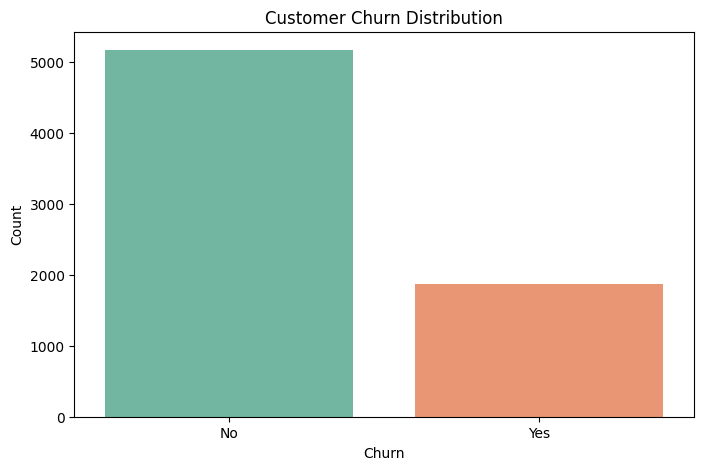

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
# Churn Distribution Visualization
plt.figure(figsize=(8,5))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

print("Churn Value Counts:")
print(df["Churn"].value_counts())

In [5]:
# Data Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.drop("customerID", axis=1, inplace=True)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Data cleaned successfully!")
print("\nMissing Values after cleaning:")
print(df.isnull().sum())
print("\nChurn column after mapping:")
print(df["Churn"].value_counts())

Data cleaned successfully!

Missing Values after cleaning:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Churn column after mapping:
Churn
0    5174
1    1869
Name: count, dtype: int64


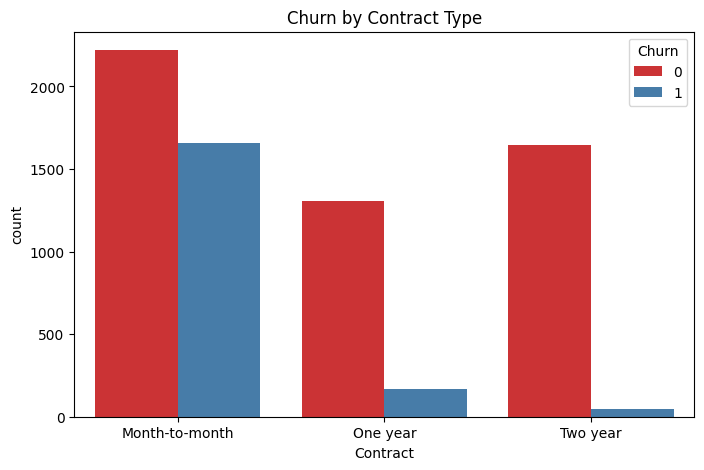

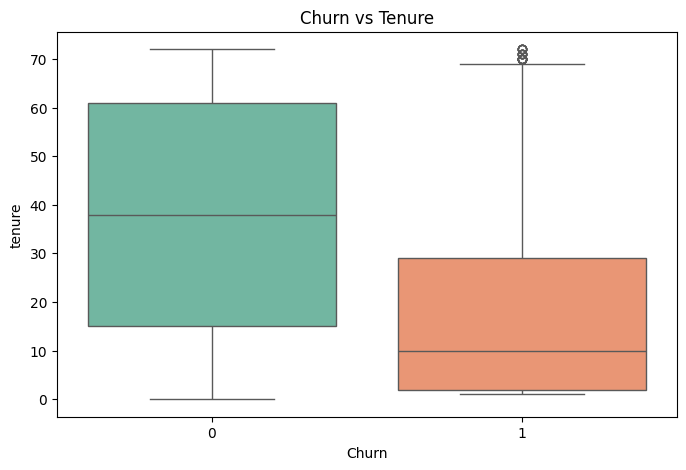

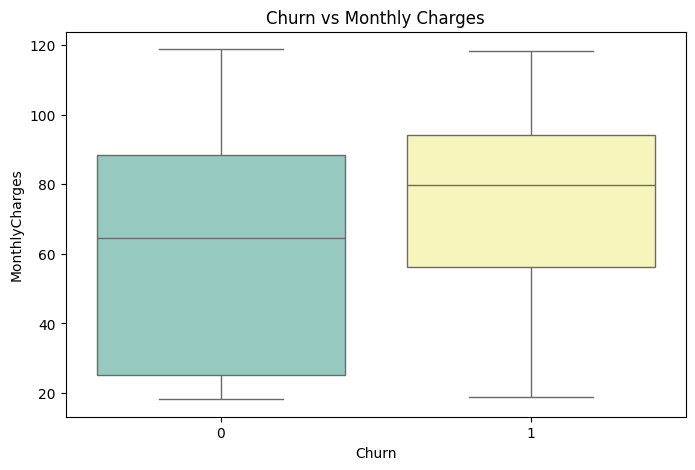

In [6]:
# Visualizations
# Churn vs Contract Type
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set1")
plt.title("Churn by Contract Type")
plt.show()

# Churn vs Tenure
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df, palette="Set2")
plt.title("Churn vs Tenure")
plt.show()

# Churn vs Monthly Charges
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set3")
plt.title("Churn vs Monthly Charges")
plt.show()

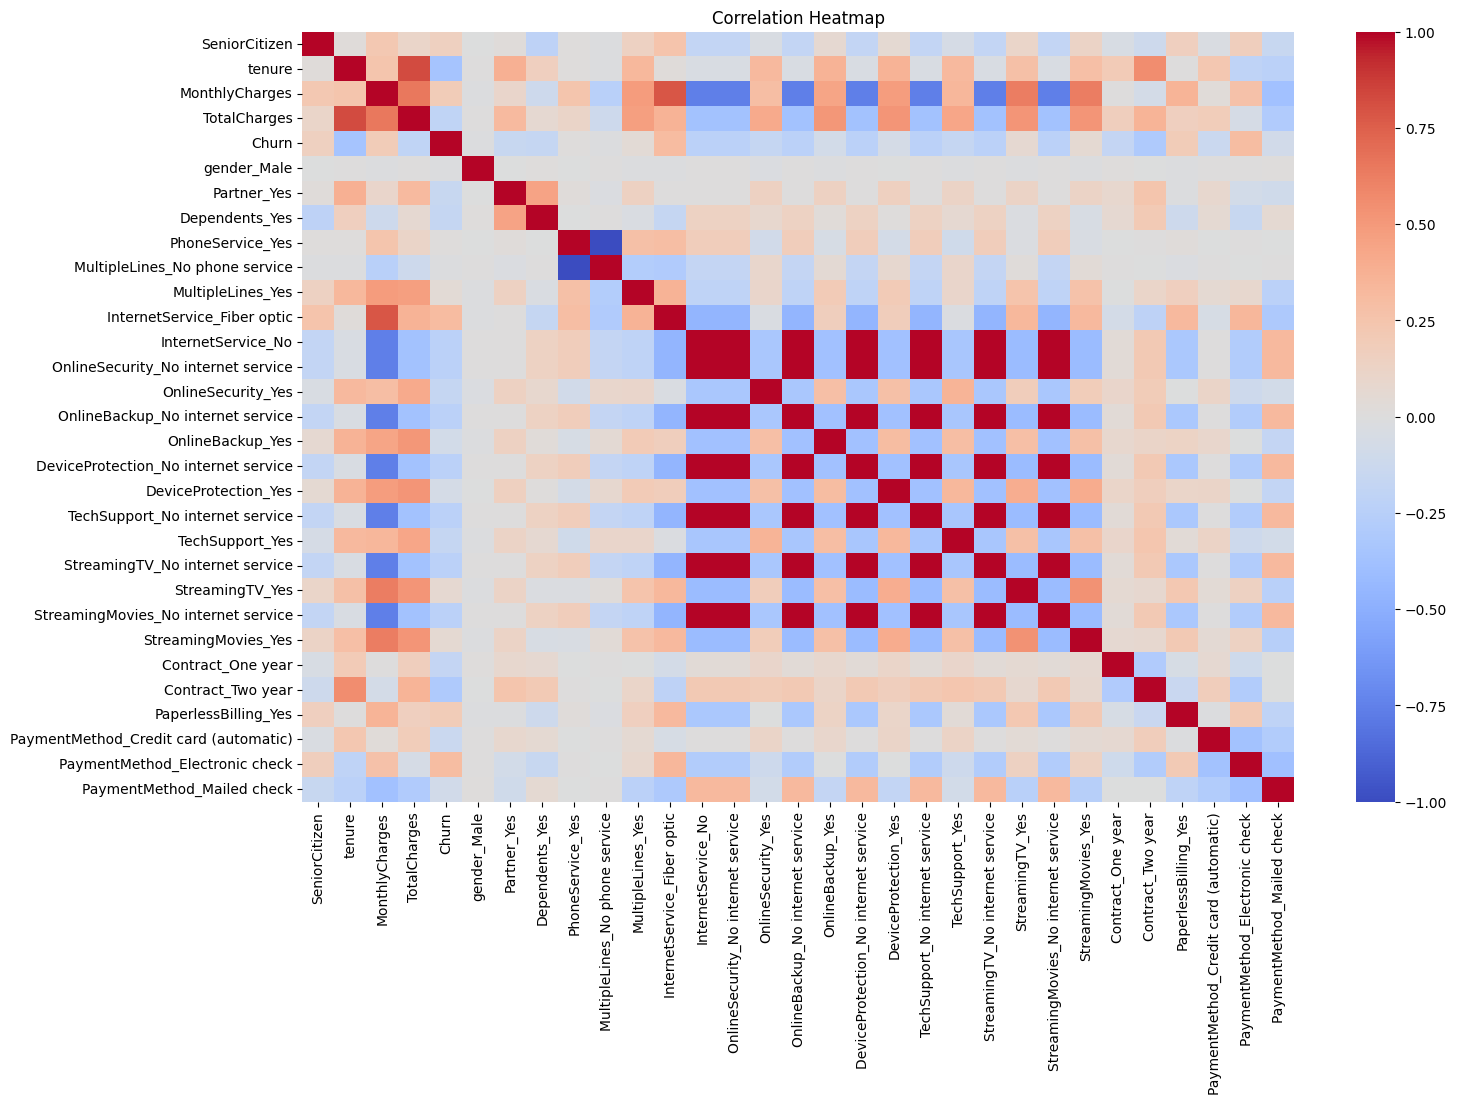

Encoded Dataset Shape: (7043, 31)


In [7]:
# Encode categorical columns and Correlation Heatmap
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(16,10))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("Encoded Dataset Shape:", df_encoded.shape)

In [8]:
# Feature Engineering & Train Test Split
df_encoded["avg_monthly_usage"] = df_encoded["tenure"] * df_encoded["MonthlyCharges"]

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("New feature created: avg_monthly_usage ✅")
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

New feature created: avg_monthly_usage ✅

Training set size: (5634, 31)
Testing set size: (1409, 31)


In [10]:
# Fill any remaining NaN values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Train ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409


XGBoost Results:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.64      0.51      0.57       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
we

In [11]:
# Customer Lifetime Value (LTV) Calculation
from sklearn.linear_model import LinearRegression

df_encoded["LTV"] = df_encoded["tenure"] * df_encoded["MonthlyCharges"]

X_ltv = df_encoded[["tenure", "MonthlyCharges", "TotalCharges"]]
y_ltv = df_encoded["LTV"]

# Fill missing values
X_ltv = X_ltv.fillna(0)

ltv_model = LinearRegression()
ltv_model.fit(X_ltv, y_ltv)

print("LTV Model Score:", ltv_model.score(X_ltv, y_ltv))
print("\nSample LTV Predictions (first 5 customers):")
print(ltv_model.predict(X_ltv[:5]))

LTV Model Score: 0.999129095547675

Sample LTV Predictions (first 5 customers):
[  20.99924358 1891.42309266  107.08747971 1844.7691937   155.75060465]


In [12]:
# Save the best model
import pickle

# Save churn model
best_model = models["Logistic Regression"]
with open("../models/churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save feature names
feature_names = list(X_train.columns)
with open("../models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Models saved successfully! ✅")
print("Feature names saved successfully! ✅")

Models saved successfully! ✅
Feature names saved successfully! ✅
